# Análisis de Vulnerabilidades de Código — CodeQL

Análisis de los hallazgos de **CodeQL** (análisis estático de seguridad) sobre el código fuente de cada repositorio.  
El objetivo es identificar los **tipos de vulnerabilidad** (reglas CWE), **severidades**, **lenguajes afectados** y **archivos críticos**.

**Archivo fuente:** `{repo}-codeql.json`  
**Campos clave:** `issues_by_severity`, `issues[].rule_id`, `issues[].severity`, `issues[].message`, `issues[].location`

In [1]:
import json
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

RESULTS_DIR   = Path('../../data/results')
CODEQL_FILES  = sorted(RESULTS_DIR.glob('*-codeql.json'))

assert CODEQL_FILES, 'No se encontraron archivos CodeQL. Ejecuta el pipeline primero.'
print(f'Archivos CodeQL encontrados: {len(CODEQL_FILES)}')
for f in CODEQL_FILES:
    print(' -', f.name)

Archivos CodeQL encontrados: 7
 - Requests-codeql.json
 - WordPress-Coding-Standards-codeql.json
 - agent-skills-codeql.json
 - gutenberg-examples-codeql.json
 - mcp-adapter-codeql.json
 - two-factor-codeql.json
 - wordpress-develop-codeql.json


## 1. Carga y normalización de hallazgos

In [2]:
SEVERIDAD_ORDEN = ['critical', 'high', 'medium', 'low', 'warning', 'note', 'none', 'desconocida']

registros = []
resumen_repo = []

for cq_file in CODEQL_FILES:
    repo = cq_file.name.replace('-codeql.json', '')
    data = json.loads(cq_file.read_text(encoding='utf-8'))

    by_sev = data.get('issues_by_severity', {})
    resumen_repo.append({'repositorio': repo, 'total': data.get('total_issues', 0), **by_sev})

    for issue in data.get('issues', []):
        location = issue.get('location', {})
        archivo = location.get('uri', location.get('file', '')) if isinstance(location, dict) else str(location)
        ext = Path(archivo).suffix.lower() if archivo else 'desconocida'

        rule_id = issue.get('rule_id', issue.get('ruleId', 'desconocida'))
        # Extraer CWE si está en el rule_id o en tags
        cwe_match = re.search(r'CWE-?(\d+)', str(rule_id) + ' ' + str(issue.get('tags', '')), re.IGNORECASE)
        cwe = f'CWE-{cwe_match.group(1)}' if cwe_match else 'sin CWE'

        registros.append({
            'repositorio':  repo,
            'rule_id':      rule_id,
            'cwe':          cwe,
            'severidad':    issue.get('severity', issue.get('level', 'desconocida')).lower(),
            'mensaje':      issue.get('message', ''),
            'archivo':      archivo,
            'extension':    ext if ext else 'sin ext.',
            'linea':        location.get('start_line', location.get('startLine')) if isinstance(location, dict) else None,
            'categoria':    issue.get('category', issue.get('tags', 'desconocida')),
        })

df = pd.DataFrame(registros)
df_resumen = pd.DataFrame(resumen_repo).set_index('repositorio').fillna(0)

print(f'Total de issues: {len(df)}')
print(f'Repositorios analizados: {len(CODEQL_FILES)}')
df.head()

Total de issues: 683
Repositorios analizados: 7


,repositorio,rule_id,cwe,severidad,mensaje,archivo,extension,linea,categoria
0,wordpress-develop,js/identity-replacement,sin CWE,warning,This replaces the empty string with itself.,,desconocida,None,desconocida
1,wordpress-develop,js/insecure-randomness,sin CWE,warning,This uses a cryptographically insecure random ...,,desconocida,None,desconocida
2,wordpress-develop,js/insecure-randomness,sin CWE,warning,This uses a cryptographically insecure random ...,,desconocida,None,desconocida
3,wordpress-develop,js/insecure-randomness,sin CWE,warning,This uses a cryptographically insecure random ...,,desconocida,None,desconocida
4,wordpress-develop,js/prototype-pollution-utility,sin CWE,warning,Properties are copied from [obj](1) to [target...,,desconocida,None,desconocida


## 2. Issues por repositorio y severidad

Resumen por repositorio:


,total,error,warning,note
repositorio,,,,
Requests,0,0,0,0
WordPress-Coding-Standards,0,0,0,0
agent-skills,0,0,0,0
gutenberg-examples,0,0,0,0
mcp-adapter,0,0,0,0
two-factor,0,0,0,0
wordpress-develop,683,0,683,0


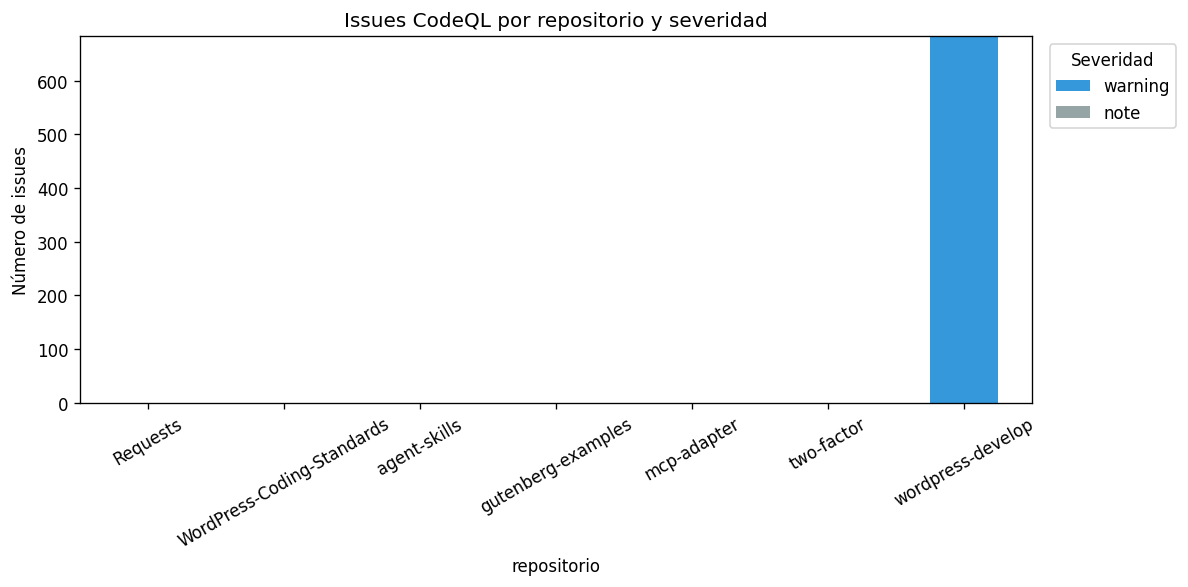

In [3]:
print('Resumen por repositorio:')
display(df_resumen)

sev_cols = [c for c in SEVERIDAD_ORDEN if c in df_resumen.columns and c != 'total']
colores_sev = {'critical': '#c0392b', 'high': '#e74c3c', 'medium': '#e67e22',
               'low': '#f1c40f', 'warning': '#3498db', 'note': '#95a5a6', 'none': '#bdc3c7'}

if sev_cols:
    df_resumen[sev_cols].plot(
        kind='bar', stacked=True, figsize=(10, 5),
        color=[colores_sev.get(c, 'gray') for c in sev_cols]
    )
    plt.title('Issues CodeQL por repositorio y severidad')
    plt.ylabel('Número de issues')
    plt.tick_params(axis='x', rotation=30)
    plt.legend(title='Severidad', bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

## 3. Tipos de regla CodeQL (categorías de vulnerabilidad)

Top 20 reglas CodeQL activadas:
rule_id
js/unused-local-variable                      310
js/useless-assignment-to-local                 42
js/missing-variable-declaration                36
js/use-before-declaration                      35
js/trivial-conditional                         34
js/superfluous-trailing-arguments              24
js/useless-expression                          15
js/xss-through-dom                             14
js/redos                                       14
js/missing-space-in-concatenation              13
js/overly-large-range                          11
js/unreachable-statement                       11
js/html-constructed-from-input                 10
js/regex/duplicate-in-character-class          10
js/unsafe-jquery-plugin                         9
js/incomplete-multi-character-sanitization      9
js/unneeded-defensive-code                      8
js/automatic-semicolon-insertion                7
js/useless-assignment-to-property               6
js/compari

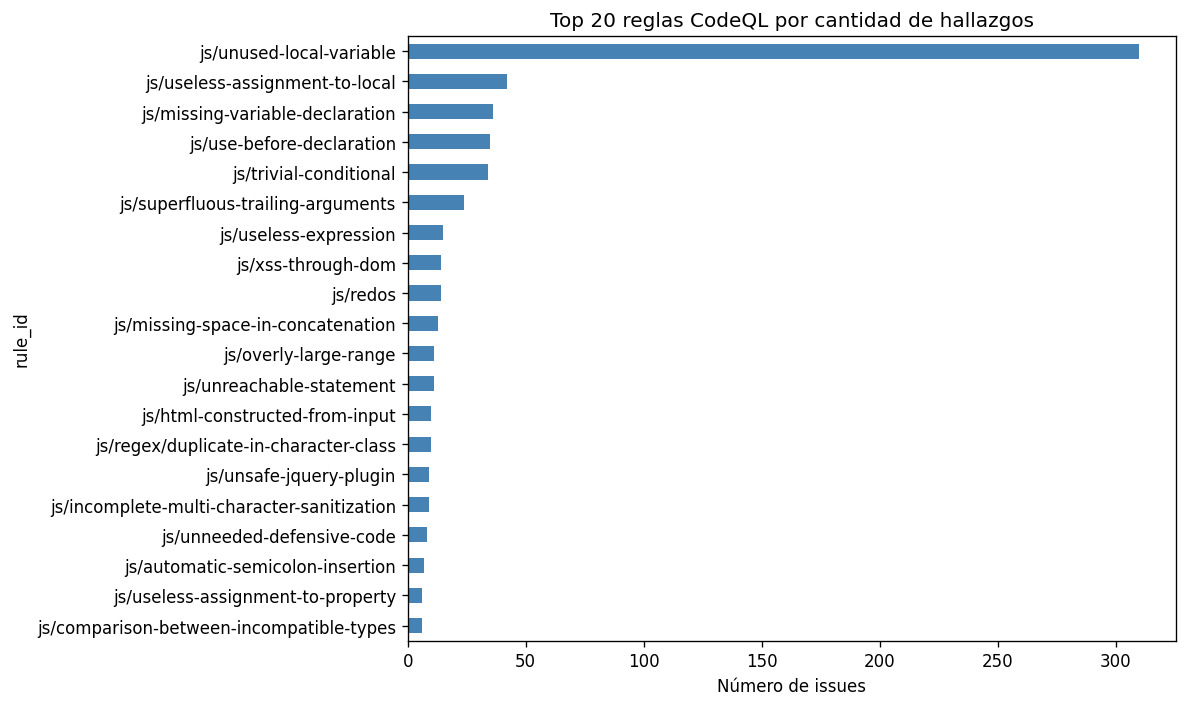

In [4]:
if df.empty:
    print('Sin hallazgos.')
else:
    rule_counts = df['rule_id'].value_counts().head(20)
    print('Top 20 reglas CodeQL activadas:')
    print(rule_counts.to_string())

    rule_counts.plot(kind='barh', figsize=(10, 6), color='steelblue')
    plt.title('Top 20 reglas CodeQL por cantidad de hallazgos')
    plt.xlabel('Número de issues')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

## 4. Distribución de severidad global

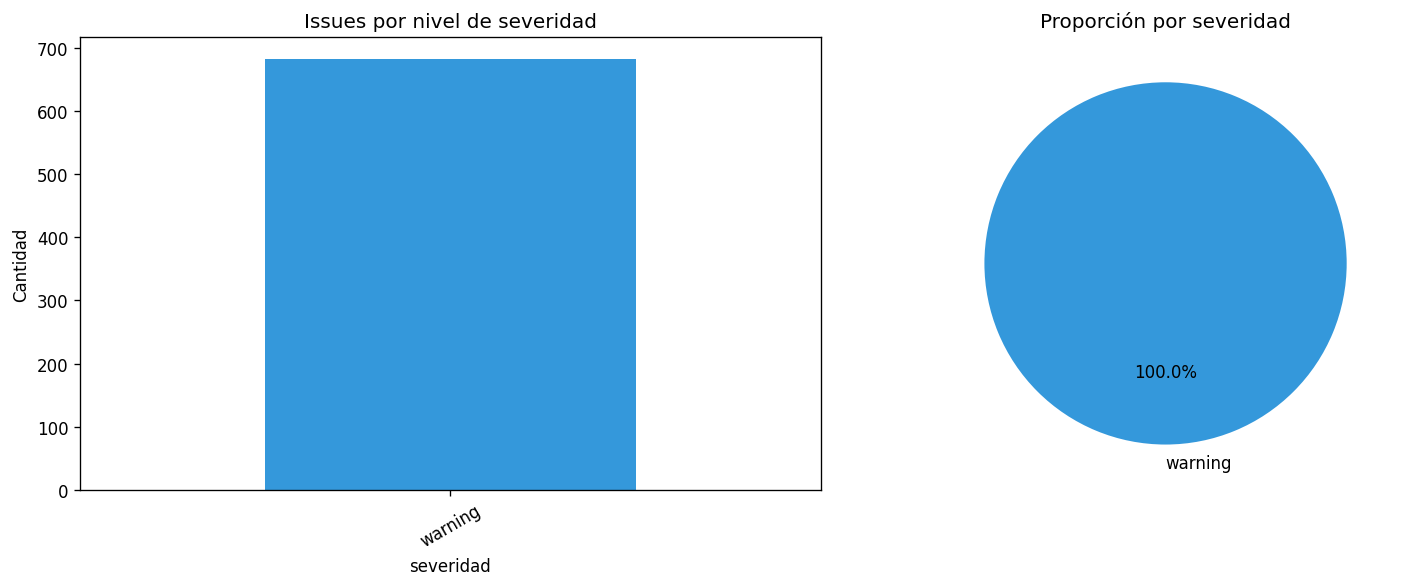

In [5]:
if not df.empty:
    sev_global = df['severidad'].value_counts()
    sev_ordered = sev_global.reindex([s for s in SEVERIDAD_ORDEN if s in sev_global.index])
    colores = [colores_sev.get(s, 'gray') for s in sev_ordered.index]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    sev_ordered.plot(kind='bar', ax=axes[0], color=colores)
    axes[0].set_title('Issues por nivel de severidad')
    axes[0].set_ylabel('Cantidad')
    axes[0].tick_params(axis='x', rotation=30)

    axes[1].pie(sev_ordered, labels=sev_ordered.index, autopct='%1.1f%%',
                colors=colores, startangle=90)
    axes[1].set_title('Proporción por severidad')
    plt.tight_layout()
    plt.show()

## 5. Clasificación CWE

CWEs detectados:
cwe
sin CWE    683


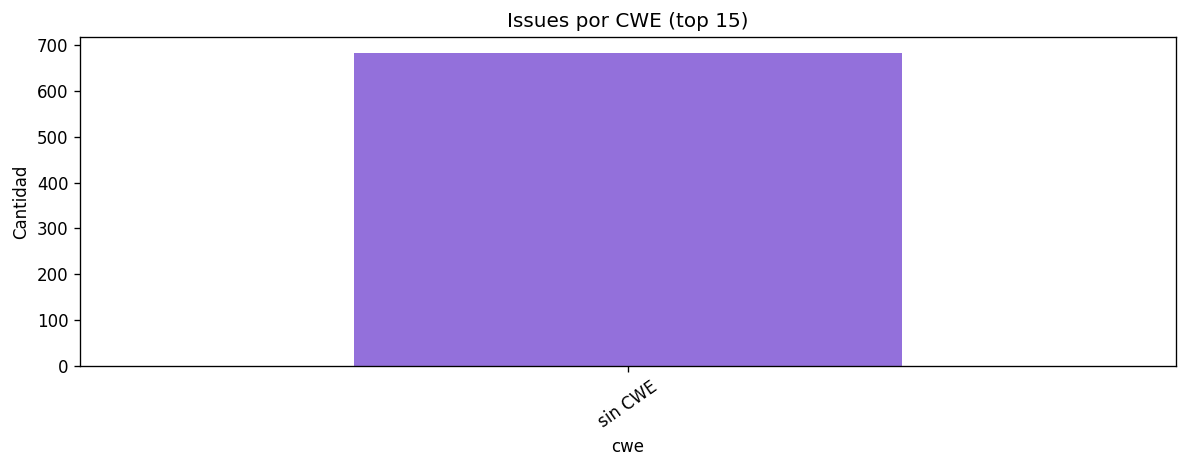

In [6]:
if not df.empty:
    cwe_counts = df['cwe'].value_counts()
    print('CWEs detectados:')
    print(cwe_counts.to_string())

    cwe_counts.head(15).plot(kind='bar', figsize=(10, 4), color='mediumpurple')
    plt.title('Issues por CWE (top 15)')
    plt.ylabel('Cantidad')
    plt.tick_params(axis='x', rotation=35)
    plt.tight_layout()
    plt.show()

## 6. Tipos de archivo afectados

Extensiones con más issues:
extension
desconocida    683


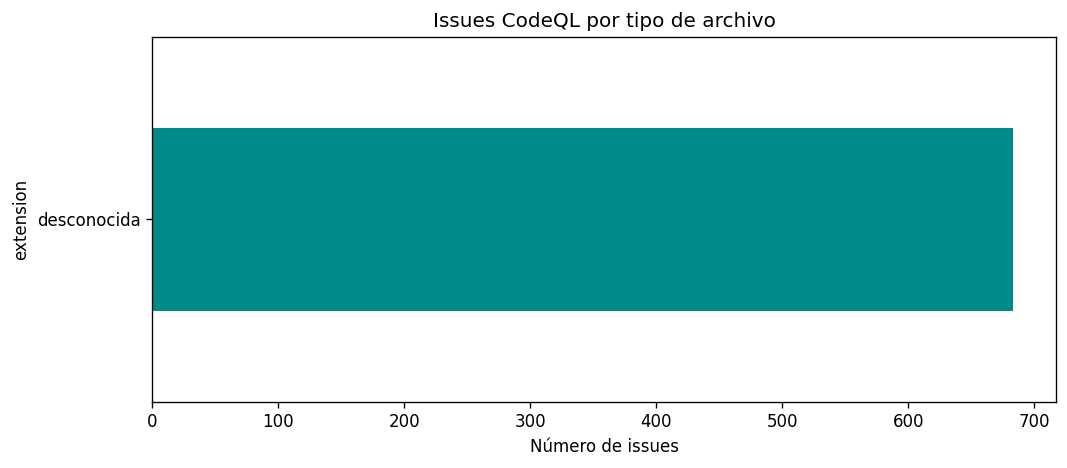

In [7]:
if not df.empty:
    ext_counts = df['extension'].value_counts().head(12)
    print('Extensiones con más issues:')
    print(ext_counts.to_string())

    ext_counts.plot(kind='barh', figsize=(9, 4), color='darkcyan')
    plt.title('Issues CodeQL por tipo de archivo')
    plt.xlabel('Número de issues')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

## 7. Archivos con mayor concentración de issues

IndexError: index 0 is out of bounds for axis 0 with size 0

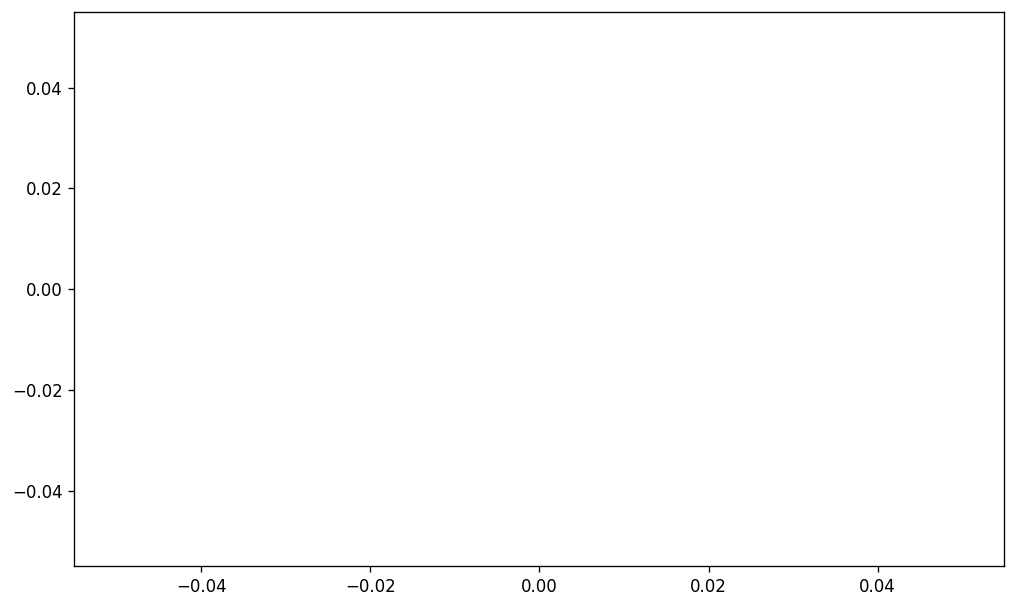

In [8]:
if not df.empty:
    top_arch = df.groupby(['repositorio', 'archivo']).size().reset_index(name='issues')
    top_arch = top_arch[top_arch['archivo'] != ''].sort_values('issues', ascending=False).head(20)
    top_arch['etiqueta'] = top_arch['repositorio'] + ' / ' + top_arch['archivo'].apply(
        lambda p: '.../' + '/'.join(Path(p).parts[-2:]) if len(Path(p).parts) > 1 else p
    )
    top_arch.set_index('etiqueta')['issues'].sort_values().plot(
        kind='barh', figsize=(10, 6), color='tomato'
    )
    plt.title('Top 20 archivos con más issues CodeQL')
    plt.xlabel('Número de issues')
    plt.tight_layout()
    plt.show()

## 8. Tabla consolidada de issues críticos y altos

In [ ]:
if not df.empty:
    criticos = df[df['severidad'].isin(['critical', 'high'])].copy()
    if criticos.empty:
        print('No hay issues críticos o altos.')
    else:
        display(criticos[['repositorio','rule_id','cwe','severidad','mensaje','archivo']]
                .sort_values(['severidad','rule_id'])
                .reset_index(drop=True))